In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [48]:
df = pd.read_csv('informacion_campana_bancaria_2026.csv')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,single,basic.9y,no,yes,no,telephone,jun,mon,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.958,5228.1,yes
1,58,retired,married,professional.course,no,yes,no,cellular,aug,mon,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.970,5228.1,no
2,48,technician,married,professional.course,no,yes,yes,cellular,nov,fri,...,3,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,no
3,39,blue-collar,single,basic.9y,no,yes,no,cellular,apr,thu,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.483,5099.1,no
4,56,services,married,basic.4y,NaN,no,no,telephone,jun,mon,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.865,5228.1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41383,21,unemployed,married,high.school,no,yes,yes,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
41384,24,blue-collar,single,basic.9y,no,yes,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,no
41385,21,student,single,basic.4y,no,no,no,cellular,mar,mon,...,2,999,0,nonexistent,-1.8,92.843,-50.0,1.520,5099.1,no
41386,52,admin.,married,high.school,no,no,no,cellular,nov,fri,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,no


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41388 entries, 0 to 41387
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41388 non-null  int64  
 1   job             41054 non-null  str    
 2   marital         41307 non-null  str    
 3   education       39644 non-null  str    
 4   default         32743 non-null  str    
 5   housing         40392 non-null  str    
 6   loan            40392 non-null  str    
 7   contact         41388 non-null  str    
 8   month           41388 non-null  str    
 9   day_of_week     41388 non-null  str    
 10  duration        41388 non-null  int64  
 11  campaign        41388 non-null  int64  
 12  pdays           41388 non-null  int64  
 13  previous        41388 non-null  int64  
 14  poutcome        41388 non-null  str    
 15  emp.var.rate    41388 non-null  float64
 16  cons.price.idx  41388 non-null  float64
 17  cons.conf.idx   41388 non-null  float64
 1

In [50]:
(df.isnull().sum()/df.shape[0])*100

age                0.000000
job                0.806997
marital            0.195709
education          4.213782
default           20.887697
housing            2.406495
loan               2.406495
contact            0.000000
month              0.000000
day_of_week        0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.price.idx     0.000000
cons.conf.idx      0.000000
euribor3m          0.000000
nr.employed        0.000000
y                  0.000000
dtype: float64

In [51]:
df.duplicated().sum()

np.int64(12)

In [52]:
df[df.duplicated()]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
6838,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
9976,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
19829,55,services,married,high.school,NaN,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
22582,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
22626,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
24813,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
24973,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
34832,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
36112,71,retired,single,university.degree,no,no,no,telephone,oct,tue,...,1,999,0,nonexistent,-3.4,92.431,-26.9,0.742,5017.5,no
39908,45,admin.,married,university.degree,no,no,no,cellular,jul,thu,...,1,999,0,nonexistent,-2.9,92.469,-33.6,1.072,5076.2,yes


In [53]:
# Mostrar registros completamente duplicados
duplicados = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

print(f"Total de filas duplicadas: {df.duplicated().sum()}")
print(f"Filas que aparecen como duplicadas (todas las copias): {len(duplicados)}\n")

duplicados

Total de filas duplicadas: 12
Filas que aparecen como duplicadas (todas las copias): 24



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
23793,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
41123,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
2168,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
22626,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
26139,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
34832,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
4049,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
6838,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
24943,36,retired,married,NaN,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
40229,36,retired,married,NaN,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no


In [54]:
df_rev = df.drop_duplicates()

In [55]:
df_rev

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,single,basic.9y,no,yes,no,telephone,jun,mon,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.958,5228.1,yes
1,58,retired,married,professional.course,no,yes,no,cellular,aug,mon,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.970,5228.1,no
2,48,technician,married,professional.course,no,yes,yes,cellular,nov,fri,...,3,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,no
3,39,blue-collar,single,basic.9y,no,yes,no,cellular,apr,thu,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.483,5099.1,no
4,56,services,married,basic.4y,NaN,no,no,telephone,jun,mon,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.865,5228.1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41383,21,unemployed,married,high.school,no,yes,yes,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
41384,24,blue-collar,single,basic.9y,no,yes,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,no
41385,21,student,single,basic.4y,no,no,no,cellular,mar,mon,...,2,999,0,nonexistent,-1.8,92.843,-50.0,1.520,5099.1,no
41386,52,admin.,married,high.school,no,no,no,cellular,nov,fri,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,no


In [56]:
df_rev.info()

<class 'pandas.DataFrame'>
Index: 41376 entries, 0 to 41387
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41376 non-null  int64  
 1   job             41042 non-null  str    
 2   marital         41295 non-null  str    
 3   education       39633 non-null  str    
 4   default         32732 non-null  str    
 5   housing         40380 non-null  str    
 6   loan            40380 non-null  str    
 7   contact         41376 non-null  str    
 8   month           41376 non-null  str    
 9   day_of_week     41376 non-null  str    
 10  duration        41376 non-null  int64  
 11  campaign        41376 non-null  int64  
 12  pdays           41376 non-null  int64  
 13  previous        41376 non-null  int64  
 14  poutcome        41376 non-null  str    
 15  emp.var.rate    41376 non-null  float64
 16  cons.price.idx  41376 non-null  float64
 17  cons.conf.idx   41376 non-null  float64
 18  eu

In [57]:
# Reemplar nulos con 'unknown' en variables categóricas

df_rev['job'] = df_rev['job'].fillna('unknown')
df_rev['marital'] = df_rev['marital'].fillna('unknown')
df_rev['education'] = df_rev['education'].fillna('unknown')
df_rev['default'] = df_rev['default'].fillna('unknown')
df_rev['housing'] = df_rev['housing'].fillna('unknown')
df_rev['loan'] = df_rev['loan'].fillna('unknown')

In [58]:
df_rev.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41376.00,41376.00,41376.00,41376.00,41376.00,41376.00,41376.00,41376.00,41376.00,41376.00
mean,40.03,257.07,2.57,962.50,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.30,2.78,186.86,0.49,1.57,0.58,4.63,1.73,72.24
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,101.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,179.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,318.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


## Gráfico 'age'

In [75]:
df_rev['age'].describe().round(2)

count    41376.00
mean        40.03
std         10.42
min         17.00
25%         32.00
50%         38.00
75%         47.00
max         98.00
Name: age, dtype: float64

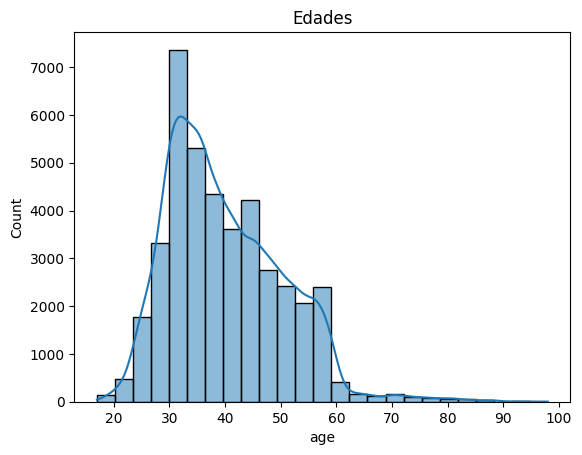

In [83]:
sns.histplot(data=df_rev, x="age", bins=25, kde=True)

plt.title("Edades")
plt.show()

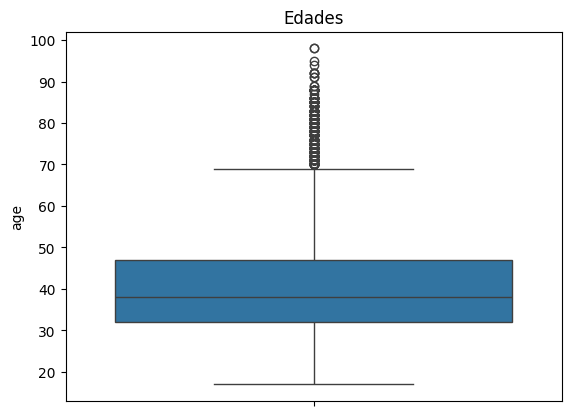

In [64]:
sns.boxplot(data=df_rev['age'])

plt.title("Edades")
plt.show()

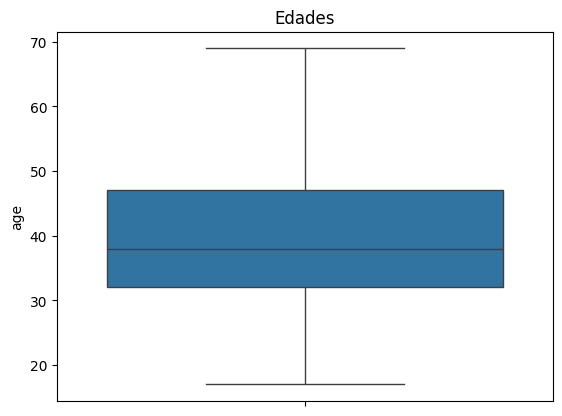

In [60]:
sns.boxplot(data=df_rev['age'], showfliers=False)

plt.title("Edades")
plt.show()

## Gráfico 'duration'

In [76]:
df_rev['duration'].describe().round(2)

count    41376.00
mean       257.07
std        259.30
min          0.00
25%        101.00
50%        179.00
75%        318.00
max       4918.00
Name: duration, dtype: float64

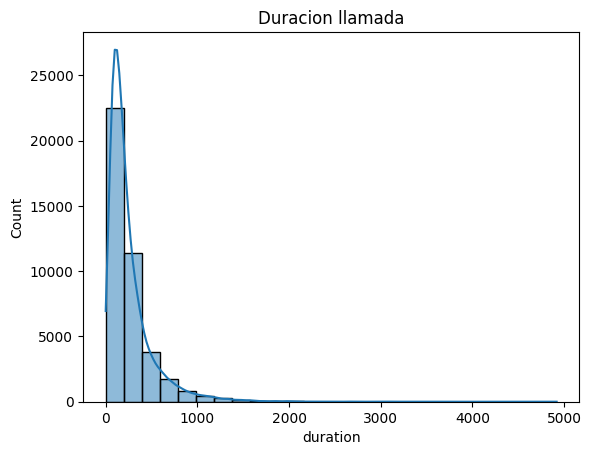

In [61]:
sns.histplot(data=df_rev, x="duration", bins=25, kde=True)

plt.title("Duracion llamada")
plt.show()

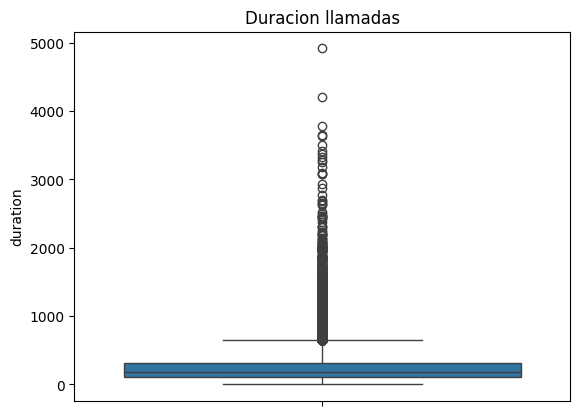

In [62]:
sns.boxplot(data=df_rev['duration'])

plt.title("Duracion llamadas")
plt.show()

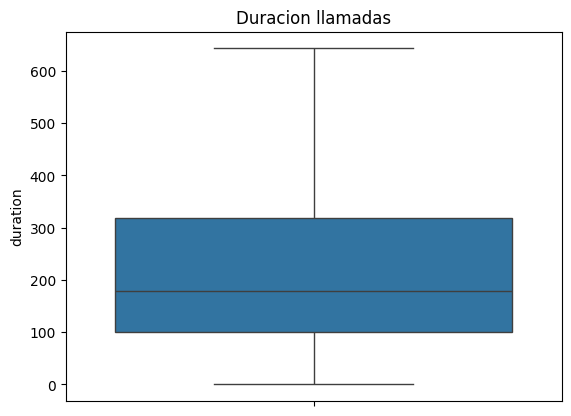

In [63]:
sns.boxplot(data=df_rev['duration'], showfliers=False)

plt.title("Duracion llamadas")
plt.show()

## Gráfico 'campaign'

In [77]:
df_rev['campaign'].describe().round(2)

count    41376.00
mean         2.57
std          2.78
min          1.00
25%          1.00
50%          2.00
75%          3.00
max         56.00
Name: campaign, dtype: float64

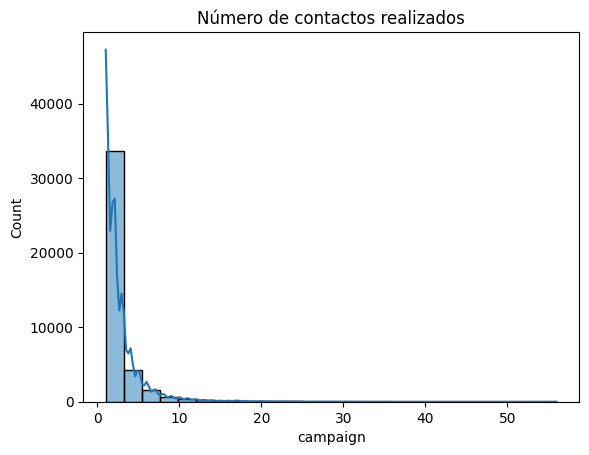

In [65]:
sns.histplot(data=df_rev, x="campaign", bins=25, kde=True)

plt.title("Número de contactos realizados")
plt.show()

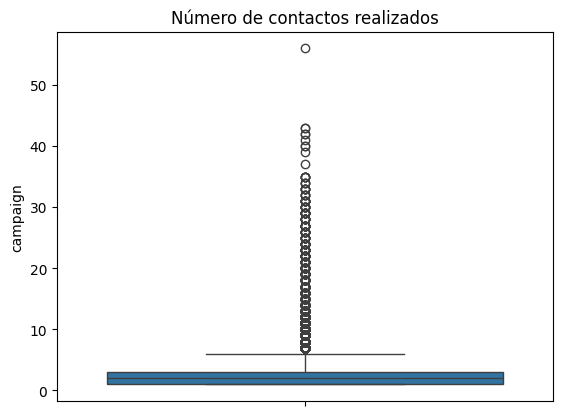

In [66]:
sns.boxplot(data=df_rev['campaign'])

plt.title("Número de contactos realizados")
plt.show()

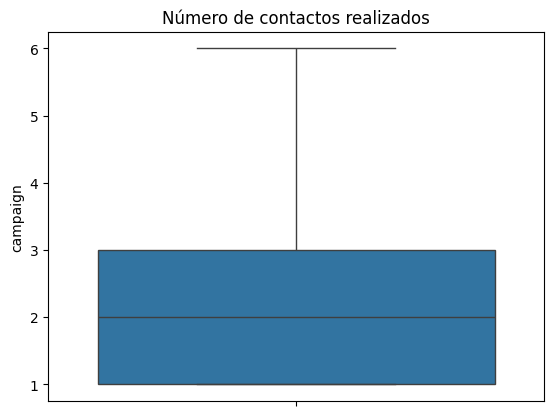

In [67]:
sns.boxplot(data=df_rev['campaign'], showfliers=False)

plt.title("Número de contactos realizados")
plt.show()

## Gráfico 'pdays'

In [78]:
df_rev['pdays'].describe().round(2)

count    41376.00
mean       962.50
std        186.86
min          0.00
25%        999.00
50%        999.00
75%        999.00
max        999.00
Name: pdays, dtype: float64

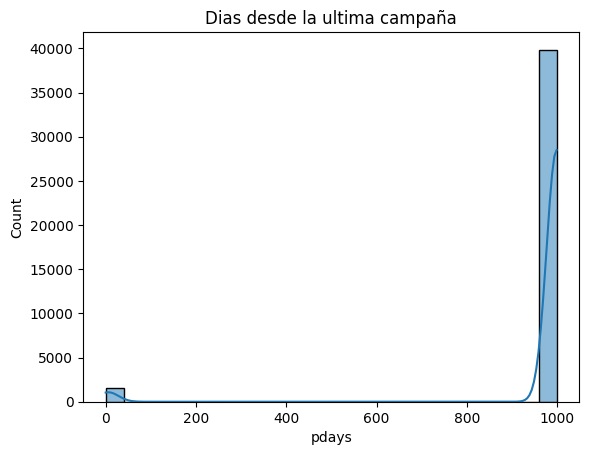

In [68]:
sns.histplot(data=df_rev, x="pdays", bins=25, kde=True)

plt.title("Dias desde la ultima campaña")
plt.show()

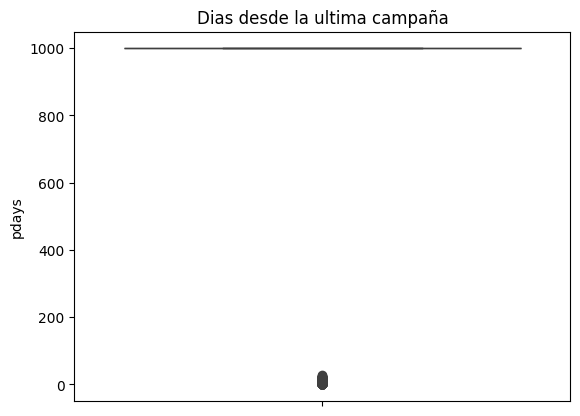

In [69]:
sns.boxplot(data=df_rev['pdays'])

plt.title("Dias desde la ultima campaña")
plt.show()

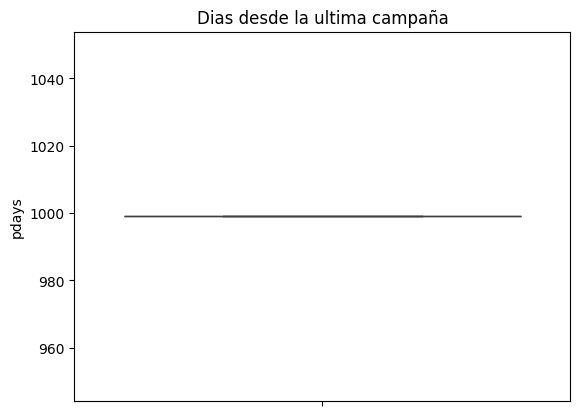

In [70]:
sns.boxplot(data=df_rev['pdays'], showfliers=False)

plt.title("Dias desde la ultima campaña")
plt.show()

## Gráfico 'previous'

In [79]:
df_rev['previous'].describe().round(2)

count    41376.00
mean         0.17
std          0.49
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          7.00
Name: previous, dtype: float64

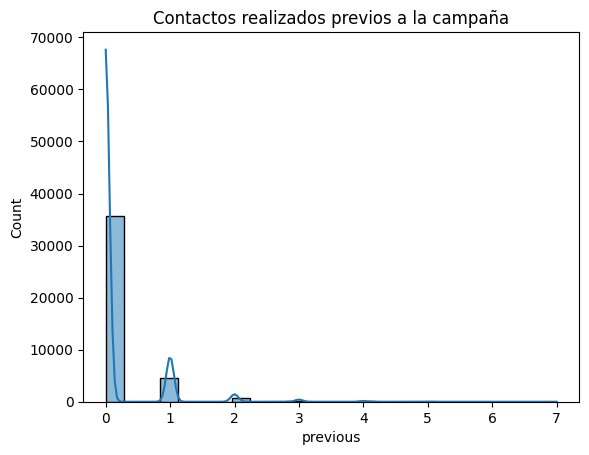

In [80]:
sns.histplot(data=df_rev, x="previous", bins=25, kde=True)

plt.title("Contactos realizados previos a la campaña")
plt.show()

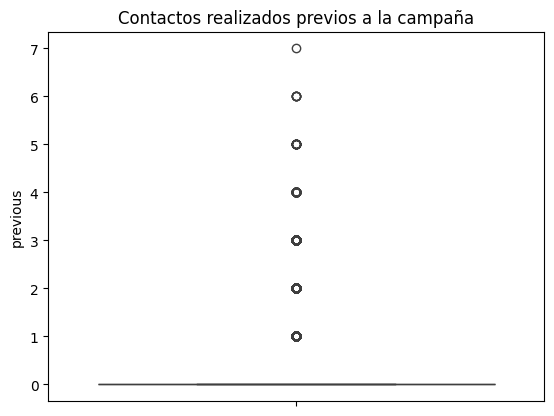

In [81]:
sns.boxplot(data=df_rev['previous'])

plt.title("Contactos realizados previos a la campaña")
plt.show()

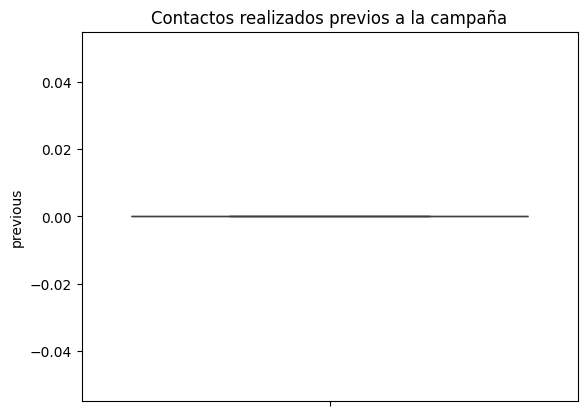

In [82]:
sns.boxplot(data=df_rev['previous'], showfliers=False)

plt.title("Contactos realizados previos a la campaña")
plt.show()